In [110]:
import pandas as pd

In [111]:
credits = pd.read_csv("tmdb_5000_credits.csv")
movies = pd.read_csv("tmdb_5000_movies.csv")

In [112]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [113]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [114]:
movies = movies.merge(credits, on="title")

In [115]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [116]:
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'crew'],
      dtype='object')

In [117]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]

In [118]:
movies.head(1)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [119]:
movies.isna().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [120]:
movies.dropna(inplace=True)

In [121]:
movies.duplicated().sum()

np.int64(0)

### convert string of list into list

In [122]:
type(movies['cast'][0])

str

In [123]:
import ast

In [124]:
def convert(text):
  L = []
  for i in ast.literal_eval(text):
    L.append(i['name'])
  return L

In [125]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [126]:
movies.head(1)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [127]:
type(movies['genres'])

pandas.core.series.Series

In [128]:
ast.literal_eval('[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]')

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

### fetch the first 3 cast name

In [129]:
movies['cast'][0]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [130]:
def convert2(text):
  L = []
  count = 0
  for i in ast.literal_eval(text):
    if count < 3:
      L.append(i['name'])
    count += 1
  return L


In [131]:
movies['cast'] = movies['cast'].apply(convert2)

In [132]:
movies.head(1)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [133]:
movies['cast'][0]

['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']

### Fetch the directer name

In [134]:
def derecter_name(text):
  L = []
  for i in ast.literal_eval(text):
    if i['job'] == 'Director':
      L.append(i['job'])
  return L
    
  

In [135]:
movies['crew'] = movies['crew'].apply(convert2)

In [136]:
movies.sample(5)

,movie_id,title,overview,genres,keywords,cast,crew
1661,46829,Barney's Version,The picaresque and touching story of the polit...,"[Comedy, Drama]","[suicide, jealousy, canada, independent film, ...","[Paul Giamatti, Dustin Hoffman, Rosamund Pike]","[Deirdre Bowen, Michele Laliberte, Nina Gold]"
2338,9829,United 93,A real time account of the events on United Fl...,"[Drama, History, Crime, Thriller, Action]","[airplane, hijacking, terror cell, emergency l...","[J.J. Johnson, Polly Adams, Trish Gates]","[John Hubbard, Lloyd Levin, Amanda Mackey]"
3826,5178,The Good Heart,"Brian Cox stars as Jacques, the curmudgeonly o...","[Drama, Comedy, Romance]","[san francisco, homeless person, bar, suicide ...","[Brian Cox, Paul Dano, Stephanie Szostak]","[Robin O'Hara, Sigurjón Sighvatsson, Dagur Kári]"
3305,374461,Mr. Church,A unique friendship develops when a little gir...,[Drama],"[cook, friendship]","[Eddie Murphy, Britt Robertson, Natascha McElh...","[Mark Isham, Bruce Beresford, David Beatty]"
3763,11536,The Misfits,"While filing for a divorce, beautiful ex-strip...","[Drama, Action, Romance]","[decision, reno, mustang, falling in love, div...","[Clark Gable, Marilyn Monroe, Montgomery Clift]","[George Tomasini, Alex North, John Huston]"


In [137]:
movies.isna().sum()

movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [138]:
def collapse(text):
  L = []
  for i in text:
    L.append(i.replace(" ", ""))
  return L

In [139]:
movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)
movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)

In [140]:
movies.head(2)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]","[StephenE.Rivkin, RickCarter, ChristopherBoyes]"
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]","[DariuszWolski, GoreVerbinski, JerryBruckheimer]"


In [141]:
movies['overview'] = movies['overview'].apply(lambda x : x.split())

In [142]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]","[StephenE.Rivkin, RickCarter, ChristopherBoyes]"
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]","[DariuszWolski, GoreVerbinski, JerryBruckheimer]"
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]","[ThomasNewman, SamMendes, AnnaPinnock]"
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]","[HansZimmer, CharlesRoven, ChristopherNolan]"
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]","[AndrewStanton, AndrewStanton, JohnLasseter]"


In [143]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [144]:
movies = movies.drop(columns=["overview",	"genres",	"keywords",	"cast",	"crew"], )

In [145]:
movies

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [146]:
# movies['tags'] = movies['tags'].str.lower()

In [147]:
movies['tags'] = movies['tags'].apply(lambda x : " ".join(x))

In [148]:
movies.head(1)

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."


In [149]:
movies['tags'] = movies['tags'].str.lower()

In [150]:
movies.head(1)

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."


### remove punctuation

In [151]:
import string
def remove_punctuation(text):
  return text.translate(str.maketrans('','',string.punctuation))

In [152]:
movies['tags'] = movies['tags'].apply(remove_punctuation)

In [153]:
movies.head(1)

,movie_id,title,tags
0,19995,Avatar,in the 22nd century a paraplegic marine is dis...


### remove stop words

In [154]:
# pip install --upgrade --force-reinstall nltk

In [155]:
import nltk
print(nltk.__version__)

3.9.3


In [156]:
from nltk.corpus import stopwords

In [157]:
stop_word = stopwords.words('english')

In [158]:
stop_word

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [159]:
def remove_stopWords(text):
  L = []
  for word in text.split():
    if word not in stop_word:
      L.append(word)
    else:
      L.append("")
      
  return " ".join(L)

In [160]:
movies['tags'] = movies['tags'].apply(remove_stopWords)

In [161]:
movies.head()

,movie_id,title,tags
0,19995,Avatar,22nd century paraplegic marine dispatched ...
1,285,Pirates of the Caribbean: At World's End,captain barbossa long believed dead come ba...
2,206647,Spectre,cryptic message bond’s past sends trail ...
3,49026,The Dark Knight Rises,following death district attorney harvey den...
4,49529,John Carter,john carter warweary former military captain...


### stemming

In [162]:
from nltk.stem.porter import PorterStemmer

In [163]:
ps = PorterStemmer()

In [164]:
def stemming(text):
  return " ".join([ps.stem(word) for word in text.split()])


In [165]:
movies['tags'] = movies['tags'].apply(stemming)

In [166]:
movies.head()

,movie_id,title,tags
0,19995,Avatar,22nd centuri parapleg marin dispatch moon pand...
1,285,Pirates of the Caribbean: At World's End,captain barbossa long believ dead come back li...
2,206647,Spectre,cryptic messag bond’ past send trail uncov sin...
3,49026,The Dark Knight Rises,follow death district attorney harvey dent bat...
4,49529,John Carter,john carter warweari former militari captain w...


In [167]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [168]:
tfidf = TfidfVectorizer(max_features=10000)

In [169]:
vector = tfidf.fit_transform(movies['tags'])

In [170]:
vector.toarray().shape

(4806, 10000)

In [171]:
movies['tags'][1]

'captain barbossa long believ dead come back life head edg earth turner elizabeth swann noth quit seem adventur fantasi action ocean drugabus exoticisland eastindiatradingcompani loveofoneslif traitor shipwreck strongwoman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnnydepp orlandobloom keiraknightley dariuszwolski goreverbinski jerrybruckheim'

In [172]:
from sklearn.metrics.pairwise import cosine_similarity

In [173]:
similarity = cosine_similarity(vector)

In [174]:
similarity

array([[1.        , 0.01591505, 0.0218102 , ..., 0.03386625, 0.00429181,
        0.        ],
       [0.01591505, 1.        , 0.02160269, ..., 0.01440678, 0.        ,
        0.        ],
       [0.0218102 , 0.02160269, 1.        , ..., 0.0190682 , 0.        ,
        0.        ],
       ...,
       [0.03386625, 0.01440678, 0.0190682 , ..., 1.        , 0.01376375,
        0.01476622],
       [0.00429181, 0.        , 0.        , ..., 0.01376375, 1.        ,
        0.00530719],
       [0.        , 0.        , 0.        , ..., 0.01476622, 0.00530719,
        1.        ]], shape=(4806, 4806))

In [175]:
# pip install seaborn

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

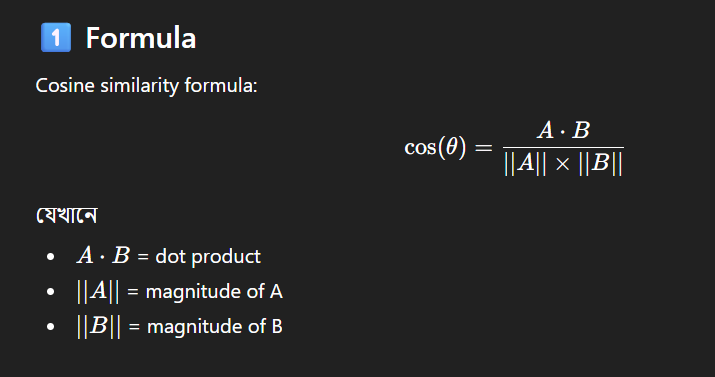

### Main Function

In [185]:
def recommend(movie):

  if movie not in movies['title'].values:
        print("Movie not found!")
        return
  
  index = movies[movies['title'] == movie].index[0]
  distance = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x : x[1])

  for i in distance[1:6]:
    print(movies.iloc[i[0]].title)
  

In [191]:
recommend('Avatar')

Titan A.E.
Aliens
Guardians of the Galaxy
Star Trek Into Darkness
Meet Dave


In [192]:
movies['title'][539]

'Titan A.E.'

In [190]:
sorted(list(enumerate(similarity[0])), reverse=True, key=lambda x : x[1])

[(0, np.float64(1.0)),
 (539, np.float64(0.17822873712985848)),
 (2405, np.float64(0.1740121418881971)),
 (94, np.float64(0.1491888633061047)),
 (47, np.float64(0.12536149621129158)),
 (778, np.float64(0.12447911342992946)),
 (3606, np.float64(0.12433561588902672)),
 (942, np.float64(0.11830940952646046)),
 (1916, np.float64(0.11682075657902656)),
 (1202, np.float64(0.11374586251307693)),
 (7, np.float64(0.11195456429250444)),
 (1342, np.float64(0.10840179115676978)),
 (260, np.float64(0.10661218726246738)),
 (838, np.float64(0.10456345355766014)),
 (582, np.float64(0.10270837113874552)),
 (507, np.float64(0.10248654010575546)),
 (2936, np.float64(0.10194378001315103)),
 (1214, np.float64(0.10067325616455841)),
 (1087, np.float64(0.09900102156296026)),
 (3536, np.float64(0.09884413065350997)),
 (1353, np.float64(0.09786261672964838)),
 (74, np.float64(0.09673810509744452)),
 (438, np.float64(0.09607661864236074)),
 (3728, np.float64(0.09485874166687638)),
 (311, np.float64(0.0948327972

In [193]:
import pickle

In [194]:
pickle.dump(movies, open("movies.pkl", "wb"))
pickle.dump(similarity, open("similarity.pkl", "wb"))

In [208]:
movies['title'].values

array(['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre',
       ..., 'Signed, Sealed, Delivered', 'Shanghai Calling',
       'My Date with Drew'], shape=(4806,), dtype=object)

In [209]:
movies

,movie_id,title,tags
0,19995,Avatar,22nd centuri parapleg marin dispatch moon pand...
1,285,Pirates of the Caribbean: At World's End,captain barbossa long believ dead come back li...
2,206647,Spectre,cryptic messag bond’ past send trail uncov sin...
3,49026,The Dark Knight Rises,follow death district attorney harvey dent bat...
4,49529,John Carter,john carter warweari former militari captain w...
...,...,...,...
4804,9367,El Mariachi,el mariachi want play guitar carri famili trad...
4805,72766,Newlyweds,newlyw coupl honeymoon upend arriv respect sis...
4806,231617,"Signed, Sealed, Delivered",sign seal deliv introduc dedic quartet civil s...
4807,126186,Shanghai Calling,ambiti new york attorney sam sent shanghai ass...
